# Week 4 Data Exploration
**Canyang Xu — AIPI 510**

## About this notebook

This notebook uses the Welltory COVID-19 and Wearables dataset. I decided to focus on **participants** and **HRV measurements** instead of trying to explore every file in the repository.

The reason is pretty simple: HRV is one of the main signals in the original research, and `participants.csv` gives me the participant-level context I need, especially the reported symptom-onset date. That lets me do more than just describe the columns — I can also connect HRV measurements to the illness timeline.

**Files used**
- `data/week4/data/participants.csv`
- `data/week4/data/hrv_measurements.csv`

**Main questions**
1. How complete and balanced is the HRV data?
2. Are some participants contributing much more data than others?
3. What do the main HRV variables look like?
4. Can I create a useful feature based on time relative to symptom onset?

To run the notebook, the CSV files should be inside the local `data/week4/data/` folder. The data itself should not be committed to Git.


## Why I did not explore every file

I wanted the EDA to stay connected to one clear question rather than become a tour of every CSV.

| File | Decision | Reason |
|---|---|---|
| `participants.csv` | Use | Participant-level context and symptom-onset date |
| `hrv_measurements.csv` | Use | Core physiological data for the research question |
| `heart_rate.csv` | Skip for now | Very large raw table and overlaps with BPM already available in HRV |
| `blood_pressure.csv` | Skip for now | Relevant, but secondary to the HRV-focused question |
| `sleep.csv` | Skip for now | Interesting behavioral context, but several fields are sparse |
| `surveys.csv` | Skip for now | Would require additional work to interpret survey scales correctly |
| `wearables.csv` | Skip for now | Adds another type of daily activity data and would widen the scope |
| `weather.csv` | Skip for now | Useful external context, but not needed for this first participant-level analysis |
| `scales_description.csv` | Reference only | Metadata for survey fields rather than a primary observation table |

I would probably bring sleep, surveys, or wearables back in if the next question were about recovery or daily behavior.


In [20]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

DATA_DIR = Path("data/week4/data")

participants = pd.read_csv(DATA_DIR / "participants.csv")
hrv = pd.read_csv(DATA_DIR / "hrv_measurements.csv")

print("participants:", participants.shape)
print("hrv_measurements:", hrv.shape)


participants: (185, 8)
hrv_measurements: (3245, 22)


## 1. First look at the data

The two files have different units of observation:

- `participants.csv` has one row per person.
- `hrv_measurements.csv` has one row per HRV measurement, so the same person can appear many times.

That repeated-measurement structure is important because 3,245 HRV rows do **not** mean 3,245 independent people.


In [21]:
print("Participants in participant table:", participants["user_code"].nunique())
print("Participants in HRV table:", hrv["user_code"].nunique())

display(participants.head())
display(hrv.head())


Participants in participant table: 185
Participants in HRV table: 185


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


In [22]:
participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"], errors="coerce"
)
hrv["measurement_datetime"] = pd.to_datetime(
    hrv["measurement_datetime"], errors="coerce"
)

measurements_per_user = hrv.groupby("user_code").size()

print("Collection window:")
print(hrv["measurement_datetime"].min(), "to", hrv["measurement_datetime"].max())

display(measurements_per_user.describe().to_frame("measurements"))


Collection window:
2019-12-31 06:08:29 to 2020-06-19 11:40:13


,measurements
count,185.000000
mean,17.540541
std,45.790517
min,1.000000
25%,1.000000
50%,4.000000
75%,12.000000
max,405.000000


### My first useful finding

The sampling is much more uneven than I expected.

- There are **185 participants** and **3,245 HRV measurements**.
- The median participant has only **4 measurements**.
- 25% of participants have only **1 measurement**.
- The most active participant has **405 measurements**.

This matters a lot. If I later build a model or compare groups using every row directly, a few highly active users could dominate the result. I would want to think about participant-level aggregation, weighting, or a repeated-measures approach before doing serious modeling.


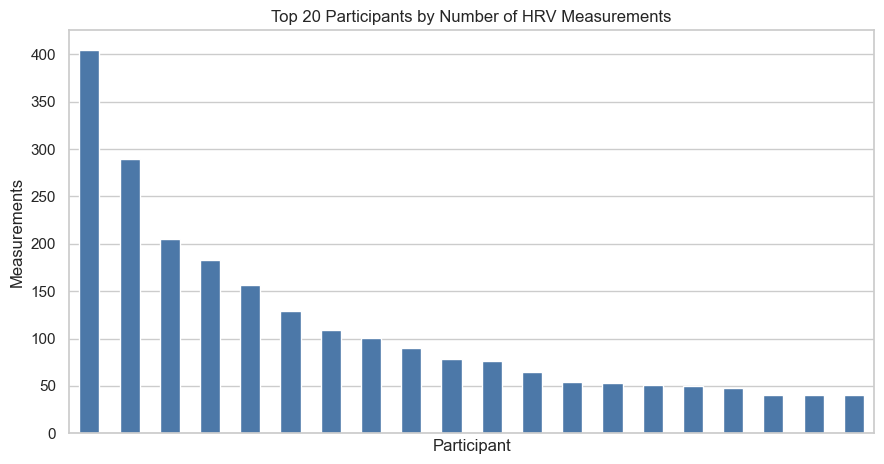

In [23]:
plt.figure(figsize=(9, 4.8))
measurements_per_user.sort_values(ascending=False).head(20).plot(
    kind="bar", color="#4C78A8"
)
plt.title("Top 20 Participants by Number of HRV Measurements")
plt.xlabel("Participant")
plt.ylabel("Measurements")
plt.xticks([])
plt.tight_layout()
plt.show()


## 2. Missing values, duplicates, and integrity

I checked missingness before deciding whether anything should be filled in. For this dataset, I do not think automatic imputation is a good default, especially for optional self-reported fields.


In [24]:
participant_missing = (
    participants.isna().mean().mul(100).sort_values(ascending=False).round(1)
)
hrv_missing = (
    hrv.isna().mean().mul(100).sort_values(ascending=False).round(1)
)

display(participant_missing.to_frame("missing_%"))
display(hrv_missing.to_frame("missing_%").head(10))


,missing_%
symptoms_onset,20.5
city,6.5
country,3.2
height,1.1
age_range,0.0
gender,0.0
user_code,0.0
weight,0.0


,missing_%
how_sleep,54.8
tags,32.2
measurement_datetime,0.0
time_of_day,0.0
user_code,0.0
rr_code,0.0
meanrr,0.0
bpm,0.0
mxdmn,0.0
sdnn,0.0


In [25]:
print("Duplicate participant rows:", participants.duplicated().sum())
print("Duplicate HRV rows:", hrv.duplicated().sum())
print("Duplicate rr_code values:", hrv["rr_code"].duplicated().sum())

print("Unique participant IDs:", participants["user_code"].is_unique)
print("Unique HRV measurement IDs:", hrv["rr_code"].is_unique)


Duplicate participant rows: 0
Duplicate HRV rows: 0
Duplicate rr_code values: 0
Unique participant IDs: True
Unique HRV measurement IDs: True


### What I would do with the missing data

The main HRV variables I use below are complete, so I do not need to impute them.

Two missingness patterns stood out:
- about **54.8%** of `how_sleep` is missing;
- about **20.5%** of participants do not have a usable symptom-onset date.

I would leave `how_sleep` missing instead of filling it with an average because it is a self-reported response. For symptom onset, I keep those participants in the general EDA, but they cannot be used in the symptom-timeline feature later.

There are no duplicate rows in these two files, and the IDs behave as expected, so I do not remove any rows here.


## 3. Main HRV variables

I kept the descriptive section fairly small and focused on a few interpretable HRV measures:

- `bpm`: heart rate during the measurement
- `sdnn` and `rmssd`: time-domain HRV measures
- `pnn50`: another HRV measure based on RR-interval differences
- `lfhf`: low-frequency / high-frequency power ratio
- `total_power`: total HRV frequency-domain power

The definitions and units come from the repository's `datatypes.md`.


In [26]:
metrics = ["bpm", "sdnn", "rmssd", "pnn50", "lfhf", "total_power"]

display(
    hrv[metrics]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
    .round(2)
)


,count,mean,std,min,5%,25%,50%,75%,95%,max
bpm,3245.0,73.26,12.20,44.00,55.00,65.00,72.00,81.00,95.80,125.00
sdnn,3245.0,52.49,29.37,9.52,18.33,32.58,46.92,64.41,107.40,206.63
rmssd,3245.0,52.81,39.35,6.34,16.83,28.98,42.87,62.48,120.24,310.80
pnn50,3245.0,20.62,18.59,0.00,1.00,6.06,16.16,29.29,56.57,91.92
lfhf,3245.0,2.40,5.75,0.03,0.16,0.40,0.86,1.97,9.85,105.62
total_power,3245.0,2630.31,3912.25,44.00,188.00,620.00,1387.00,2906.00,9443.80,41118.00


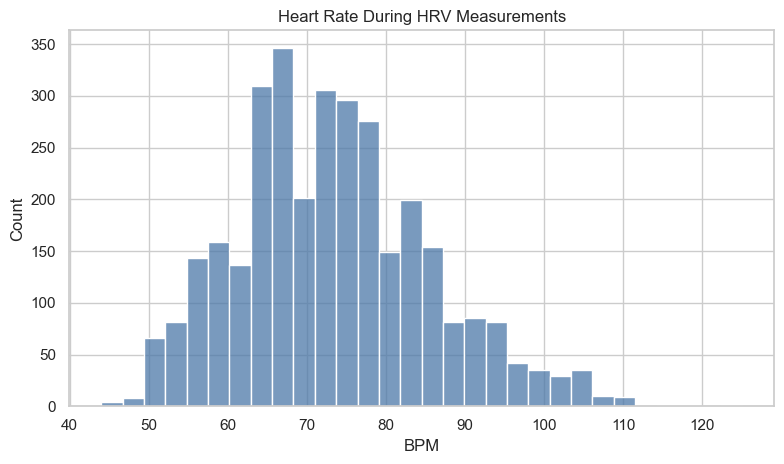

In [27]:
plt.figure(figsize=(8, 4.8))
sns.histplot(hrv["bpm"], bins=30, color="#4C78A8")
plt.title("Heart Rate During HRV Measurements")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


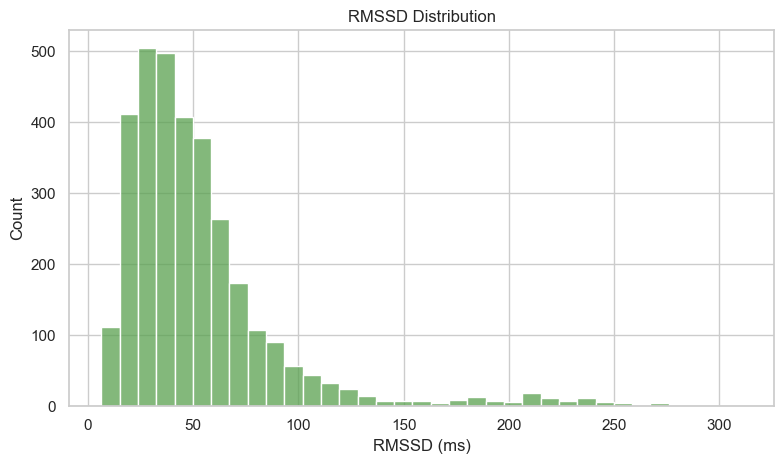

In [28]:
plt.figure(figsize=(8, 4.8))
sns.histplot(hrv["rmssd"], bins=35, color="#59A14F")
plt.title("RMSSD Distribution")
plt.xlabel("RMSSD (ms)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The BPM distribution is fairly compact, but RMSSD has a long right tail. I would not immediately treat that tail as bad data because unusual physiological values can still be real measurements. I prefer to flag possible outliers first and keep the raw observations.


## 4. Outlier check


In [29]:
q1 = hrv["rmssd"].quantile(0.25)
q3 = hrv["rmssd"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

hrv["rmssd_outlier_iqr"] = (hrv["rmssd"] < lower) | (hrv["rmssd"] > upper)

print(f"IQR range used for flagging: {lower:.2f} to {upper:.2f}")
print("Flagged rows:", hrv["rmssd_outlier_iqr"].sum())
print("Percent flagged:", f'{hrv["rmssd_outlier_iqr"].mean() * 100:.1f}%')


IQR range used for flagging: -21.27 to 112.73
Flagged rows: 195
Percent flagged: 6.0%


The IQR rule flags about **6%** of the RMSSD measurements. I keep them in the dataset. At this stage, the flag is more useful than deleting rows because I do not have an external clinical reference telling me those measurements are wrong.


## 5. Relationships between HRV variables


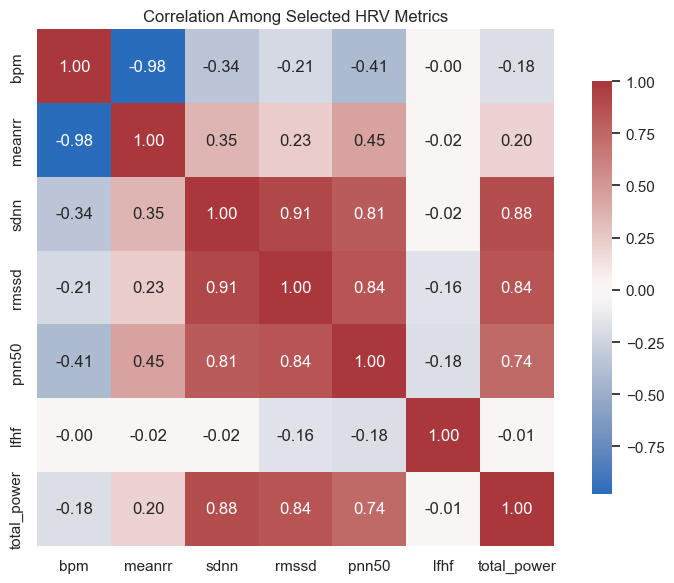

In [30]:
corr_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lfhf", "total_power"]
corr = hrv[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Among Selected HRV Metrics")
plt.tight_layout()
plt.show()


A few relationships are very strong. For example, SDNN, RMSSD, pNN50, and total power move together, while BPM and mean RR are almost perfectly negatively related.

My takeaway is not that one variable causes another. The more practical point is that these features contain overlapping information. If I used all of them in a model later, I would check for redundancy rather than assuming every HRV column adds something new.


## 6. New feature: time relative to symptom onset

This is the part I found most interesting.

A raw timestamp tells me **when** an HRV measurement happened, but for this dataset I care more about **when it happened relative to the participant's symptoms**.

I joined the HRV measurements to the participant table and created:

`days_from_symptom_onset = measurement date - reported symptom-onset date`

I also grouped that value into a simpler `symptom_phase` feature.


In [31]:
merged = hrv.merge(
    participants[
        ["user_code", "gender", "age_range", "country", "symptoms_onset"]
    ],
    on="user_code",
    how="left",
    validate="many_to_one",
)

merged["days_from_symptom_onset"] = (
    merged["measurement_datetime"].dt.normalize()
    - merged["symptoms_onset"].dt.normalize()
).dt.days

def symptom_phase(days):
    if pd.isna(days):
        return np.nan
    if days < 0:
        return "Pre-onset"
    if days <= 7:
        return "0-7 days"
    if days <= 14:
        return "8-14 days"
    return ">14 days"

merged["symptom_phase"] = merged["days_from_symptom_onset"].apply(symptom_phase)

print(
    "Measurements with symptom-onset alignment:",
    merged["days_from_symptom_onset"].notna().sum(),
    "of",
    len(merged),
)

display(
    merged["symptom_phase"]
    .value_counts(dropna=False)
    .to_frame("measurements")
)


Measurements with symptom-onset alignment: 2816 of 3245


,measurements
symptom_phase,
>14 days,1669
Pre-onset,732
NaN,429
8-14 days,267
0-7 days,148


In [32]:
phase_order = ["Pre-onset", "0-7 days", "8-14 days", ">14 days"]

phase_summary = (
    merged.dropna(subset=["symptom_phase"])
    .groupby("symptom_phase")
    .agg(
        measurements=("rr_code", "count"),
        participants=("user_code", "nunique"),
        median_rmssd=("rmssd", "median"),
        median_sdnn=("sdnn", "median"),
        median_bpm=("bpm", "median"),
    )
    .reindex(phase_order)
    .round(2)
)

display(phase_summary)


,measurements,participants,median_rmssd,median_sdnn,median_bpm
symptom_phase,,,,,
Pre-onset,732,21,45.18,47.30,72.0
0-7 days,148,44,40.58,44.99,73.0
8-14 days,267,56,43.74,45.56,75.0
>14 days,1669,102,44.21,46.95,73.0


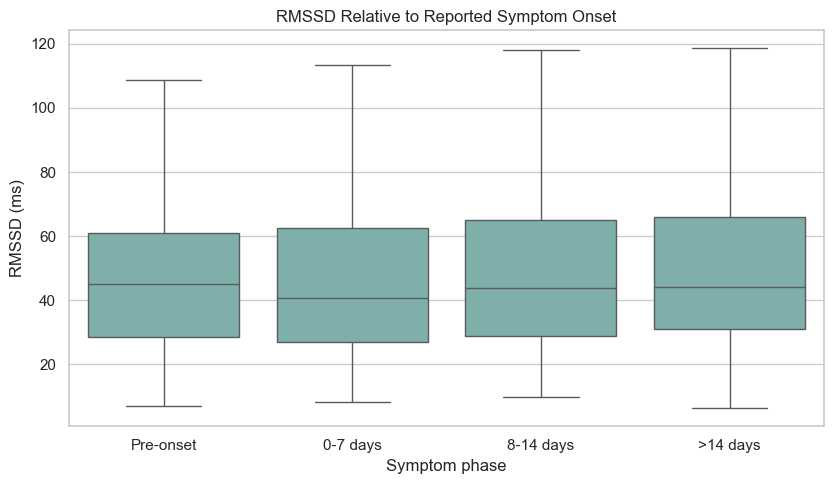

In [33]:
plt.figure(figsize=(8.5, 5))
sns.boxplot(
    data=merged.dropna(subset=["symptom_phase"]),
    x="symptom_phase",
    y="rmssd",
    order=phase_order,
    color="#76B7B2",
    showfliers=False,
)
plt.title("RMSSD Relative to Reported Symptom Onset")
plt.xlabel("Symptom phase")
plt.ylabel("RMSSD (ms)")
plt.tight_layout()
plt.show()


### What I see here

The median RMSSD is slightly lower in the first 0–7 days after reported symptom onset than in the pre-onset group, but I would **not** call that a disease effect from this EDA.

The bigger issue is sampling:
- only **21 participants** contribute pre-onset measurements;
- the `>14 days` group has **1,669 measurements from 102 participants**;
- individual participants still contribute very different numbers of rows.

So the feature is useful, but the simple boxplot is only a first look. A better follow-up would compare participants within themselves over time or use a model that accounts for repeated measurements.


## 7. One more pattern I checked: age

Since `participants.csv` includes age groups, I did one small check to see whether HRV looks different across age ranges. I did **not** use every raw HRV row for this comparison. Instead, I first calculated each participant's median RMSSD so that people with hundreds of measurements would not automatically count more than people with only a few.

There is a visible pattern from ages 18–24 through 45–54: the group median falls from about **60 ms** to about **43 ms**. The two oldest groups do not continue that pattern, but those groups are very small — only **9** and **7** participants — so I would not treat that reversal as evidence of a real age effect.

For me, the useful takeaway is that age may be worth controlling for later, but this dataset is not balanced enough across age groups to make a strong claim from this plot alone.


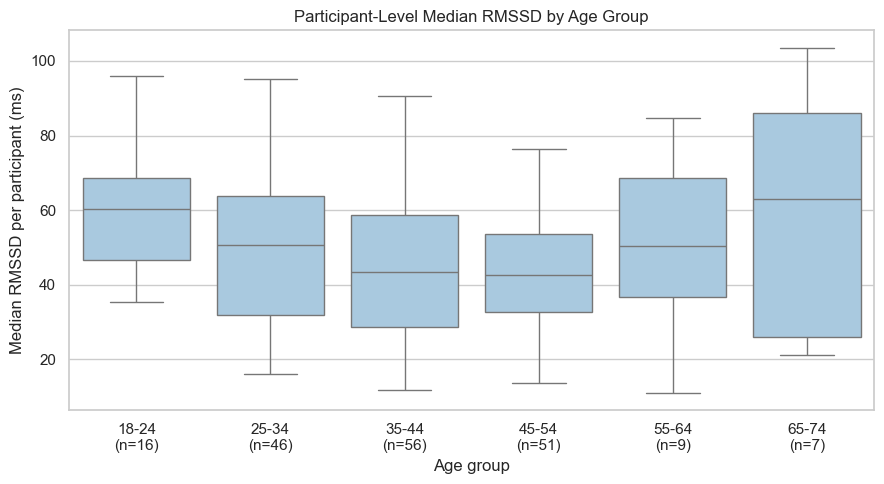

In [34]:
participant_rmssd = (
    hrv.groupby("user_code", as_index=False)["rmssd"]
    .median()
    .rename(columns={"rmssd": "median_rmssd"})
    .merge(participants[["user_code", "age_range"]], on="user_code", how="left")
)

age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]
age_counts = participant_rmssd["age_range"].value_counts().reindex(age_order)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=participant_rmssd,
    x="age_range",
    y="median_rmssd",
    order=age_order,
    color="#A0CBE8",
    showfliers=False,
)
plt.xticks(
    range(len(age_order)),
    [f"{age}\n(n={age_counts[age]})" for age in age_order]
)
plt.title("Participant-Level Median RMSSD by Age Group")
plt.xlabel("Age group")
plt.ylabel("Median RMSSD per participant (ms)")
plt.tight_layout()
plt.show()


## 8. Data quality assessment

**Profiling**  
The selected data has 185 participants and 3,245 HRV measurements. The HRV table is repeated-measures data rather than one row per person.

**Completeness**  
The core HRV metrics used in this notebook are complete. Missingness is mostly in optional/self-reported fields and symptom-onset metadata.

**Accuracy**  
The values are internally plausible enough for EDA, but I do not have clinical ground truth for each measurement. Because of that, I flag statistical outliers instead of automatically deleting them.

**Consistency**  
Participant IDs join cleanly between the two files, dates parse correctly, and the HRV table uses the expected time-of-day categories.

**Integrity**  
`user_code` is unique in the participant table and `rr_code` is unique in the HRV table. The many-to-one merge preserves the intended relationship.

**Lineage / provenance**  
According to the supplied repository README, the Welltory team collected this anonymized dataset during its 2020 COVID-19 research. HRV measurements came through the Welltory app using supported heart-rate devices or smartphone PPG. Variable definitions and units are documented in `datatypes.md`.


## Final takeaways

The biggest thing I learned from this EDA is that **row count is misleading here**. There are thousands of HRV measurements, but they are very unevenly distributed across only 185 participants. That is the data issue I would keep in mind first before doing any modeling.

A few other takeaways:

- the main HRV variables are complete enough for a clean first analysis;
- some HRV features are strongly correlated and may be redundant;
- I would flag unusual HRV values before deciding whether to remove them;
- aligning measurements to symptom onset creates a more meaningful feature than using calendar time alone;
- RMSSD looks lower across the 18–54 age groups as age increases, but the oldest groups are too small to support a strong age-related conclusion;
- the symptom-phase comparison is interesting, but the group imbalance means it should stay exploratory.

I intentionally left the other CSV files out of the main EDA. They are not useless — I just did not need them to answer this first HRV-focused question. If I continued the project, my next step would probably be to add **sleep or survey data** and see whether behavioral or self-reported symptoms explain some of the variation in HRV.
